# Heart Disease Risk Prediction with Explainable AI

## Project Overview

This project develops a machine learning pipeline to predict the presence of heart disease using the **UCI Cleveland Heart Disease dataset**. The workflow covers data quality checks, exploratory data analysis, preprocessing, model comparison, cross-validation, hyperparameter tuning, final evaluation, and model explainability with SHAP.

**Task:** Binary classification  
**Target:** `0 = No Heart Disease`, `1 = Heart Disease`  
**Dataset source:** UCI Machine Learning Repository — Heart Disease  
https://archive.ics.uci.edu/dataset/45/heart+disease

> **Note:** This notebook is an educational and portfolio project. It is not a clinical diagnostic tool and should not be used for medical decision-making.


## 1. Environment and Libraries

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version: 3.0.6
NumPy version: 2.5.3
Scikit-learn version: 1.9.1


## 2. Data Loading and Initial Inspection

In [100]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(url, names=columns)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [101]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 303
Number of columns: 14


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 35.0 KB


In [103]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 3. Data Quality Inspection


In [104]:
# Checking Unique Values

for column in df.columns:
    print(f"{column}: {df[column].unique()}")
    print("-" * 50)

age: [63. 67. 37. 41. 56. 62. 57. 53. 44. 52. 48. 54. 49. 64. 58. 60. 50. 66.
 43. 40. 69. 59. 42. 55. 61. 65. 71. 51. 46. 45. 39. 68. 47. 34. 35. 29.
 70. 77. 38. 74. 76.]
--------------------------------------------------
sex: [1. 0.]
--------------------------------------------------
cp: [1. 4. 3. 2.]
--------------------------------------------------
trestbps: [145. 160. 120. 130. 140. 172. 150. 110. 132. 117. 135. 112. 105. 124.
 125. 142. 128. 170. 155. 104. 180. 138. 108. 134. 122. 115. 118. 100.
 200.  94. 165. 102. 152. 101. 126. 174. 148. 178. 158. 192. 129. 144.
 123. 136. 146. 106. 156. 154. 114. 164.]
--------------------------------------------------
chol: [233. 286. 229. 250. 204. 236. 268. 354. 254. 203. 192. 294. 256. 263.
 199. 168. 239. 275. 266. 211. 283. 284. 224. 206. 219. 340. 226. 247.
 167. 230. 335. 234. 177. 276. 353. 243. 225. 302. 212. 330. 175. 417.
 197. 198. 290. 253. 172. 273. 213. 305. 216. 304. 188. 282. 185. 232.
 326. 231. 269. 267. 248. 360. 258. 3

In [105]:
# Checking Missing Value Symbols

print("Missing value symbols in each column:")
print((df == "?").sum())

Missing value symbols in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [106]:
# Checking Duplicate Rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [107]:
# Inspecting Target Distribution

print(df["target"].value_counts().sort_index())

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [108]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 4. Data Cleaning

In [109]:
# Missing Symbols -> NaN

df = df.replace("?", np.nan)

print("Missing values after replacing '?':")
print(df.isnull().sum())

Missing values after replacing '?':
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [110]:
# Columns -> Numeric

df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

print(df[["ca", "thal"]].dtypes)

ca      float64
thal    float64
dtype: object


In [111]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [112]:
# Converting Target to Binary

df["target"] = (df["target"] > 0).astype(int)

print("Binary target distribution:")
print(df["target"].value_counts().sort_index())

Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [113]:
# Data Cleaning Check

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["target"].value_counts().sort_index())

print("\nData types:")
print(df.dtypes)

Dataset shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Duplicate rows:
0

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


 ## 5 - Exploratory Data Analysis

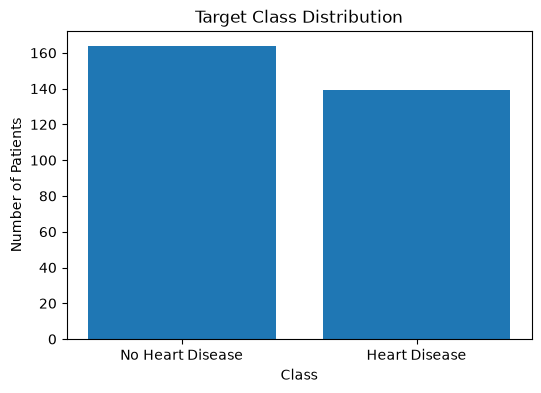

target
0    164
1    139
Name: count, dtype: int64


In [114]:
# Target Class Distribution
target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Heart Disease", "Heart Disease"], target_counts.values)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.show()

print(target_counts)

In [115]:
target_percentage = df["target"].value_counts(normalize=True).sort_index() * 100

print("Target class percentages:")
print(target_percentage.round(2))

Target class percentages:
target
0    54.13
1    45.87
Name: proportion, dtype: float64


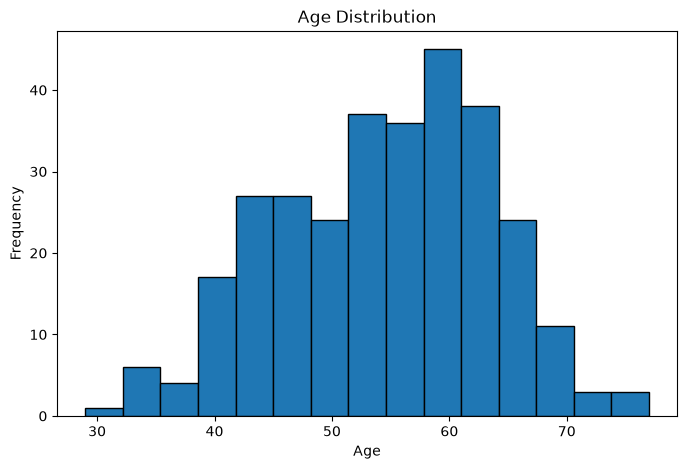

In [116]:
# Age Distribution

plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=15, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

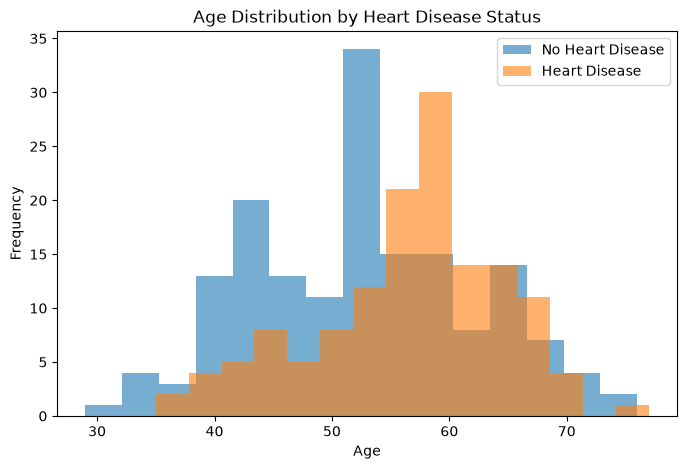

In [117]:
# Age by Heart Disease Status

plt.figure(figsize=(8, 5))

plt.hist(
    df[df["target"] == 0]["age"],
    bins=15,
    alpha=0.6,
    label="No Heart Disease"
)

plt.hist(
    df[df["target"] == 1]["age"],
    bins=15,
    alpha=0.6,
    label="Heart Disease"
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()

plt.show()

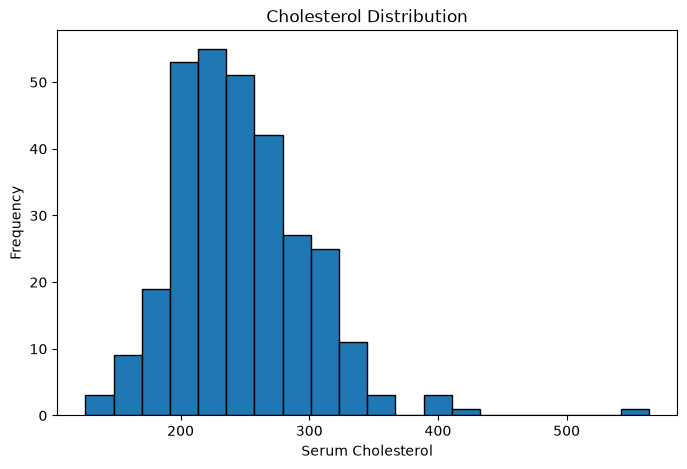

In [118]:
# Cholesterol Distribution

plt.figure(figsize=(8, 5))

plt.hist(df["chol"], bins=20, edgecolor="black")

plt.title("Cholesterol Distribution")
plt.xlabel("Serum Cholesterol")
plt.ylabel("Frequency")

plt.show()

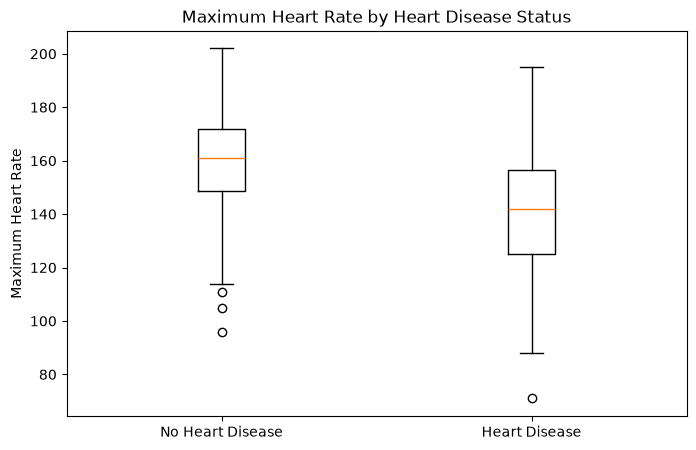

In [119]:
# Maximum Heart Rate by Target

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["target"] == 0]["thalach"],
        df[df["target"] == 1]["thalach"]
    ],
    tick_labels=["No Heart Disease", "Heart Disease"]
)

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.ylabel("Maximum Heart Rate")

plt.show()

In [120]:
# Mean Feature Values by Target

mean_by_target = df.groupby("target")[
    ["age", "trestbps", "chol", "thalach", "oldpeak"]
].mean()

mean_by_target

,age,trestbps,chol,thalach,oldpeak
target,,,,,
0,52.585366,129.250000,242.640244,158.378049,0.586585
1,56.625899,134.568345,251.474820,139.258993,1.574101


### 5.1 Categorical Features and Correlation Analysis

In [121]:
# Heart Disease Rate by Sex

sex_rate = df.groupby("sex")["target"].mean() * 100

print("Heart disease rate by sex:")
print(sex_rate.round(2))

Heart disease rate by sex:
sex
0.0    25.77
1.0    55.34
Name: target, dtype: float64


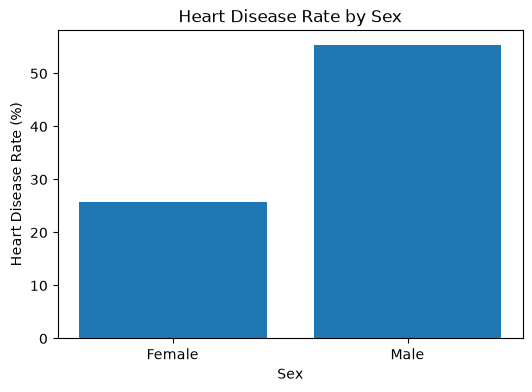

In [122]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Female", "Male"],
    sex_rate.values
)

plt.title("Heart Disease Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Heart Disease Rate (%)")

plt.show()

In [123]:
# Heart Disease Rate by Chest Pain Type

cp_rate = df.groupby("cp")["target"].mean() * 100

print("Heart disease rate by chest pain type:")
print(cp_rate.round(2))

Heart disease rate by chest pain type:
cp
1.0    30.43
2.0    18.00
3.0    20.93
4.0    72.92
Name: target, dtype: float64


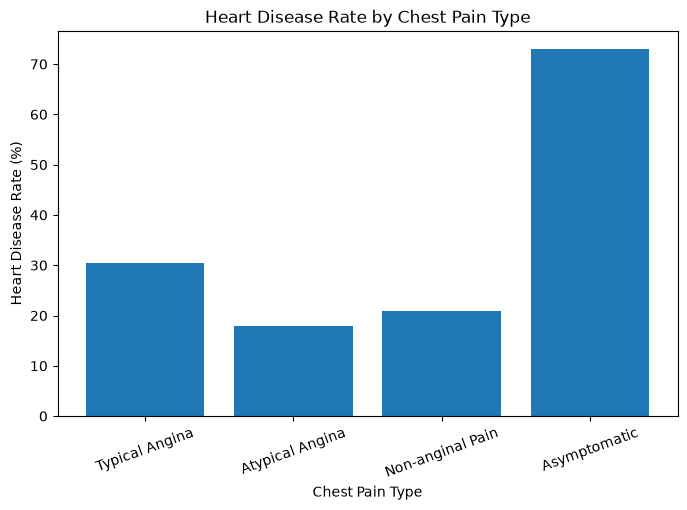

In [124]:
plt.figure(figsize=(8, 5))

plt.bar(
    [
        "Typical Angina",
        "Atypical Angina",
        "Non-anginal Pain",
        "Asymptomatic"
    ],
    cp_rate.values
)

plt.title("Heart Disease Rate by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Heart Disease Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [125]:
# Heart Disease Rate by Exercise-Induced Angina

exang_rate = df.groupby("exang")["target"].mean() * 100

print("Heart disease rate by exercise-induced angina:")
print(exang_rate.round(2))

Heart disease rate by exercise-induced angina:
exang
0.0    30.88
1.0    76.77
Name: target, dtype: float64


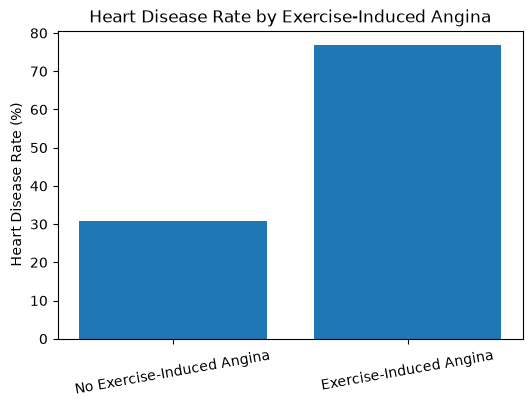

In [126]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["No Exercise-Induced Angina", "Exercise-Induced Angina"],
    exang_rate.values
)

plt.title("Heart Disease Rate by Exercise-Induced Angina")
plt.ylabel("Heart Disease Rate (%)")
plt.xticks(rotation=10)

plt.show()

In [127]:
# Correlation Matrix

correlation_matrix = df.corr()

correlation_matrix.round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.00,-0.10,0.10,0.28,0.21,0.12,0.15,-0.39,0.09,0.20,0.16,0.36,0.13,0.22
sex,-0.10,1.00,0.01,-0.06,-0.20,0.05,0.02,-0.05,0.15,0.10,0.04,0.09,0.38,0.28
cp,0.10,0.01,1.00,-0.04,0.07,-0.04,0.07,-0.33,0.38,0.20,0.15,0.23,0.27,0.41
trestbps,0.28,-0.06,-0.04,1.00,0.13,0.18,0.15,-0.05,0.06,0.19,0.12,0.10,0.13,0.15
chol,0.21,-0.20,0.07,0.13,1.00,0.01,0.17,-0.00,0.06,0.05,-0.00,0.12,0.01,0.09
fbs,0.12,0.05,-0.04,0.18,0.01,1.00,0.07,-0.01,0.03,0.01,0.06,0.15,0.07,0.03
restecg,0.15,0.02,0.07,0.15,0.17,0.07,1.00,-0.08,0.08,0.11,0.13,0.13,0.02,0.17
thalach,-0.39,-0.05,-0.33,-0.05,-0.00,-0.01,-0.08,1.00,-0.38,-0.34,-0.39,-0.26,-0.28,-0.42
exang,0.09,0.15,0.38,0.06,0.06,0.03,0.08,-0.38,1.00,0.29,0.26,0.15,0.33,0.43
oldpeak,0.20,0.10,0.20,0.19,0.05,0.01,0.11,-0.34,0.29,1.00,0.58,0.30,0.34,0.42


In [128]:
# Correlation with Target

target_correlations = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values(ascending=False)
)

print(target_correlations.round(3))

thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
thalach    -0.417
Name: target, dtype: float64


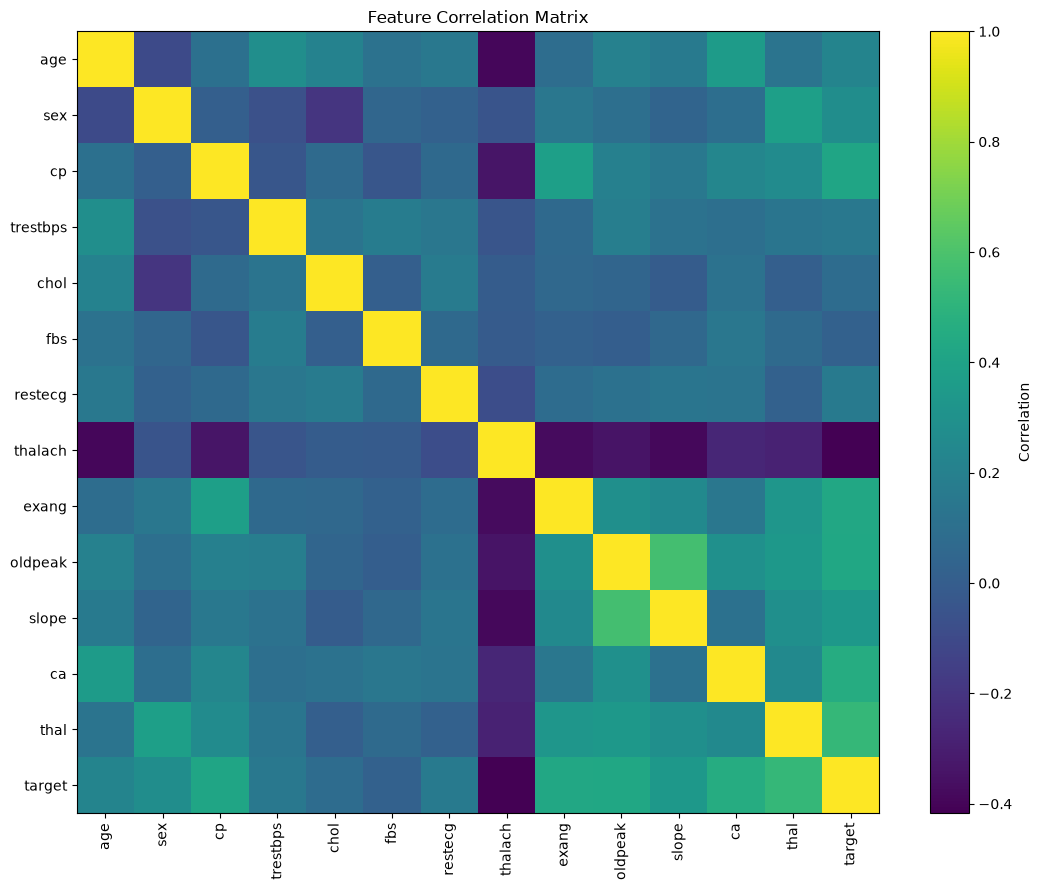

In [129]:
plt.figure(figsize=(11, 9))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## 6. Feature Definition and Train/Test Split

In [130]:
# Features and Target

X = df.drop("target", axis=1)
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (303, 13)
Target shape: (303,)


In [131]:
# Defining Feature Groups

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [132]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (242, 13)
Test set size: (61, 13)


In [133]:
# Verify Train/Test Class Distribution

print("Training target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

Test target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


In [134]:
# Checking Missing Values in Training and Test Sets

print("Training set missing values:")
print(X_train.isnull().sum())

print("\nTest set missing values:")
print(X_test.isnull().sum())

Training set missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          3
thal        2
dtype: int64

Test set missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          1
thal        0
dtype: int64


## 7. Preprocessing Pipeline

Separate preprocessing pipelines are created for numerical and categorical features.

Numerical features are imputed using the median and standardized.

Categorical features are imputed using the most frequent category and transformed using one-hot encoding.

Both pipelines are combined using a ColumnTransformer.

In [135]:
# Importing Preprocessing Tools

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [136]:
# Numerical Preprocessing Pipeline

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

numerical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [137]:
# Categorical Preprocessing Pipeline

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [138]:
# Combine Preprocessing Pipelines

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [139]:
# Fit Preprocessor on Training Data

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Preprocessed training shape:", X_train_preprocessed.shape)

print("\nOriginal test shape:", X_test.shape)
print("Preprocessed test shape:", X_test_preprocessed.shape)

Original training shape: (242, 13)
Preprocessed training shape: (242, 28)

Original test shape: (61, 13)
Preprocessed test shape: (61, 28)


In [140]:
print("Training matrix type:", type(X_train_preprocessed))
print("Test matrix type:", type(X_test_preprocessed))

print("\nNumber of training samples:", X_train_preprocessed.shape[0])
print("Number of test samples:", X_test_preprocessed.shape[0])

Training matrix type: <class 'numpy.ndarray'>
Test matrix type: <class 'numpy.ndarray'>

Number of training samples: 242
Number of test samples: 61


In [141]:
# Inspect Preprocessed Feature Names

feature_names = preprocessor.get_feature_names_out()

print("Number of features after preprocessing:", len(feature_names))

for feature in feature_names:
    print(feature)

Number of features after preprocessing: 28
numerical__age
numerical__trestbps
numerical__chol
numerical__thalach
numerical__oldpeak
categorical__sex_0.0
categorical__sex_1.0
categorical__cp_1.0
categorical__cp_2.0
categorical__cp_3.0
categorical__cp_4.0
categorical__fbs_0.0
categorical__fbs_1.0
categorical__restecg_0.0
categorical__restecg_1.0
categorical__restecg_2.0
categorical__exang_0.0
categorical__exang_1.0
categorical__slope_1.0
categorical__slope_2.0
categorical__slope_3.0
categorical__ca_0.0
categorical__ca_1.0
categorical__ca_2.0
categorical__ca_3.0
categorical__thal_3.0
categorical__thal_6.0
categorical__thal_7.0


## 8. Baseline Model: Logistic Regression

In [142]:
# Train Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=1
)

logistic_model.fit(X_train_preprocessed, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [143]:
# Make Predictions

y_pred = logistic_model.predict(X_test_preprocessed)

y_prob = logistic_model.predict_proba(X_test_preprocessed)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob[:10])

First 10 predicted classes:
[0 0 1 1 1 0 0 0 0 0]

First 10 predicted probabilities:
[0.04754885 0.21109345 0.99452652 0.99744787 0.73942751 0.19987411
 0.01482203 0.18174892 0.47586823 0.05733364]


In [144]:
# Evaluation of Baseline Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.8361
Precision: 0.8462
Recall   : 0.7857
F1-score : 0.8148
ROC-AUC  : 0.9015


In [145]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Heart Disease", "Heart Disease"]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.83      0.88      0.85        33
   Heart Disease       0.85      0.79      0.81        28

        accuracy                           0.84        61
       macro avg       0.84      0.83      0.83        61
    weighted avg       0.84      0.84      0.84        61



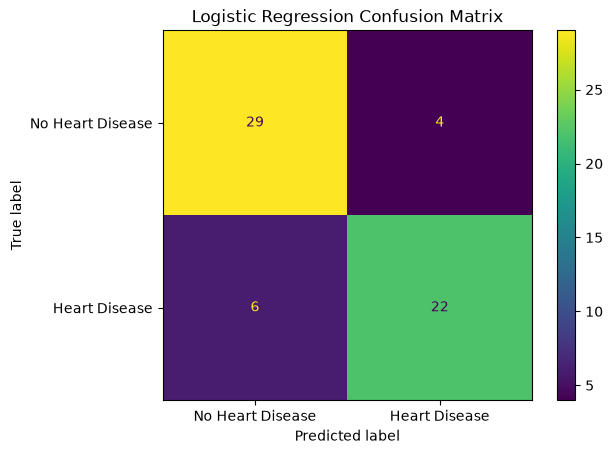

In [146]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

display.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

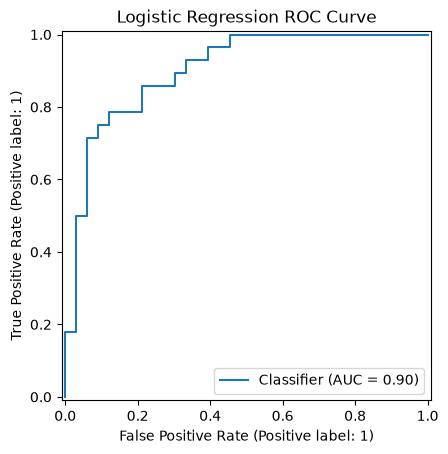

In [147]:
# ROC Curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression ROC Curve")
plt.show()

## 9. Multiple Model Comparison


In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [149]:
# Defining Models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=1
    )
}

In [150]:
# Train and Evaluate Models

results = []

for model_name, model in models.items():

    model.fit(X_train_preprocessed, y_train)

    y_pred_model = model.predict(X_test_preprocessed)
    y_prob_model = model.predict_proba(X_test_preprocessed)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_model)
    precision = precision_score(y_test, y_pred_model)
    recall = recall_score(y_test, y_pred_model)
    f1 = f1_score(y_test, y_pred_model)
    roc_auc = roc_auc_score(y_test, y_prob_model)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

C:\Users\ehabr\anaconda3\envs\Projects\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [151]:
# Model Comparison Table

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8361,0.8462,0.7857,0.8148,0.9015
1,Random Forest,0.8033,0.7857,0.7857,0.7857,0.8793
2,SVM,0.8197,0.8148,0.7857,0.8000,0.8712
3,KNN,0.8525,0.8800,0.7857,0.8302,0.8598
4,Gradient Boosting,0.7049,0.6667,0.7143,0.6897,0.8160
5,Decision Tree,0.7213,0.6897,0.7143,0.7018,0.7208


## 10. Cross-Validation

In [152]:
# Define Cross-Validation Strategy

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

print(cv)

StratifiedKFold(n_splits=5, random_state=1, shuffle=True)


In [153]:
# Define Cross-Validation Metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [154]:
# Cross-Validate All Models

cv_results = []

for model_name, model in models.items():

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

C:\Users\ehabr\anaconda3\envs\Projects\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ehabr\anaconda3\envs\Projects\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ehabr\anaconda3\envs\Projects\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ehabr\anaconda3\envs\Projects\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was dep

In [155]:
# Cross-Validation Results

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="ROC-AUC Mean",
    ascending=False
).reset_index(drop=True)

cv_results_df.round(4)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.8429,0.0390,0.8413,0.8202,0.8284,0.9230,0.0258
1,Random Forest,0.8223,0.0448,0.8218,0.7846,0.8014,0.9102,0.0170
2,SVM,0.8513,0.0356,0.8597,0.8115,0.8335,0.9052,0.0273
3,KNN,0.8141,0.0318,0.8479,0.7300,0.7830,0.8838,0.0296
4,Gradient Boosting,0.7894,0.0265,0.7948,0.7304,0.7605,0.8769,0.0241
5,Decision Tree,0.7314,0.0260,0.7060,0.7123,0.7076,0.7302,0.0283


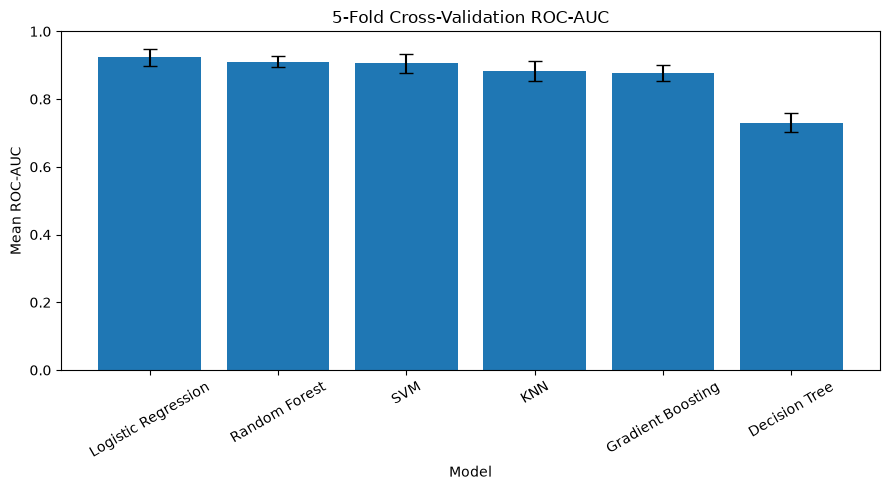

In [156]:
# Cross-Validation ROC-AUC Comparison

plt.figure(figsize=(9, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["ROC-AUC Mean"],
    yerr=cv_results_df["ROC-AUC Std"],
    capsize=5
)

plt.title("5-Fold Cross-Validation ROC-AUC")
plt.xlabel("Model")
plt.ylabel("Mean ROC-AUC")
plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning


In [157]:
# Creating Logistic Regression Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=1
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, def

In [158]:
# Define Logistic Regression Parameter Grid

logistic_param_grid = {
    "model__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

logistic_param_grid

{'model__C': [0.001, 0.01, 0.1, 1, 10, 100]}

In [159]:
# Run Grid Search

from sklearn.model_selection import GridSearchCV

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

logistic_grid_search.fit(X_train, y_train)

print("Grid search completed.")

Grid search completed.


In [160]:
# Best Logistic Regression Parameters

print("Best parameters:")
print(logistic_grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(logistic_grid_search.best_score_, 4))

Best parameters:
{'model__C': 1}

Best cross-validation ROC-AUC:
0.923


In [161]:
# Inspecting Grid Search Results

grid_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

grid_summary = grid_results[
    [
        "param_model__C",
        "mean_test_score",
        "std_test_score",
        "mean_train_score"
    ]
].copy()

grid_summary = grid_summary.sort_values(
    by="mean_test_score",
    ascending=False
)

grid_summary.round(4)

,param_model__C,mean_test_score,std_test_score,mean_train_score
3,1.000,0.9230,0.0258,0.9503
4,10.000,0.9189,0.0266,0.9520
2,0.100,0.9188,0.0131,0.9401
5,100.000,0.9179,0.0295,0.9522
1,0.010,0.9035,0.0170,0.9189
0,0.001,0.8960,0.0248,0.9063


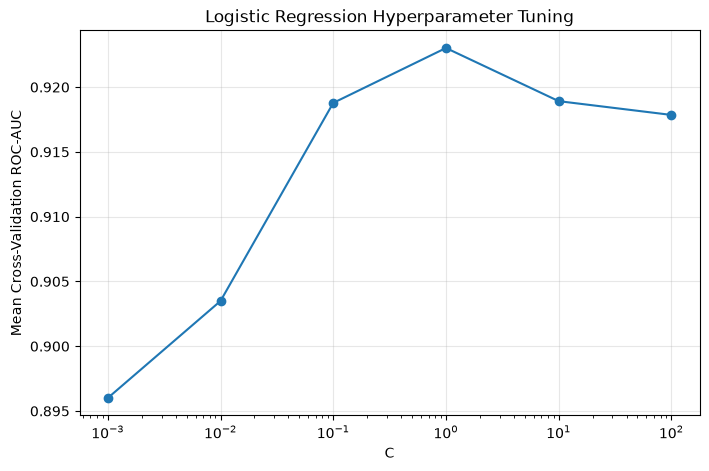

In [162]:
# Regularization Strength vs Cross-Validation Performance

plot_results = grid_summary.sort_values(
    by="param_model__C"
)

plt.figure(figsize=(8, 5))

plt.semilogx(
    plot_results["param_model__C"].astype(float),
    plot_results["mean_test_score"],
    marker="o"
)

plt.xlabel("C")
plt.ylabel("Mean Cross-Validation ROC-AUC")
plt.title("Logistic Regression Hyperparameter Tuning")

plt.grid(alpha=0.3)

plt.show()

### 11.1 Tuning Additional Candidate Models

In [163]:
# Creating Random Forest Pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=1
            )
        )
    ]
)

In [164]:
# Define Random Forest Parameter Grid

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [165]:
# Tune Random Forest

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

print("\nBest Random Forest CV ROC-AUC:")
print(round(rf_grid_search.best_score_, 4))

Best Random Forest parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Random Forest CV ROC-AUC:
0.9152


In [166]:
# SVM Pipeline

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            SVC(
                probability=True,
                random_state=1
            )
        )
    ]
)

In [167]:
# Define SVM Parameter Grid

svm_param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

In [168]:
# Tune SVM

svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

svm_grid_search.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_grid_search.best_params_)

print("\nBest SVM CV ROC-AUC:")
print(round(svm_grid_search.best_score_, 4))

Best SVM parameters:
{'model__C': 1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

Best SVM CV ROC-AUC:
0.9174


C:\Users\ehabr\anaconda3\envs\Projects\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [169]:
# Comparing Tuned Candidate Models

tuned_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Best CV ROC-AUC": [
        logistic_grid_search.best_score_,
        rf_grid_search.best_score_,
        svm_grid_search.best_score_
    ]
})

tuned_comparison = tuned_comparison.sort_values(
    by="Best CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

tuned_comparison.round(4)

,Model,Best CV ROC-AUC
0,Logistic Regression,0.9230
1,SVM,0.9174
2,Random Forest,0.9152


## 12. Final Model Evaluation


In [170]:
final_model = logistic_grid_search.best_estimator_

print("Final model:")
print(final_model)

print("\nSelected parameters:")
print(logistic_grid_search.best_params_)

Final model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                

In [171]:
final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

print("Number of test predictions:", len(final_predictions))

Number of test predictions: 61


In [172]:
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)
final_roc_auc = roc_auc_score(y_test, final_probabilities)

print("Final Logistic Regression Test Results")
print("--------------------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

Final Logistic Regression Test Results
--------------------------------------
Accuracy : 0.8361
Precision: 0.8462
Recall   : 0.7857
F1-score : 0.8148
ROC-AUC  : 0.9015


In [173]:
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.83      0.88      0.85        33
   Heart Disease       0.85      0.79      0.81        28

        accuracy                           0.84        61
       macro avg       0.84      0.83      0.83        61
    weighted avg       0.84      0.84      0.84        61



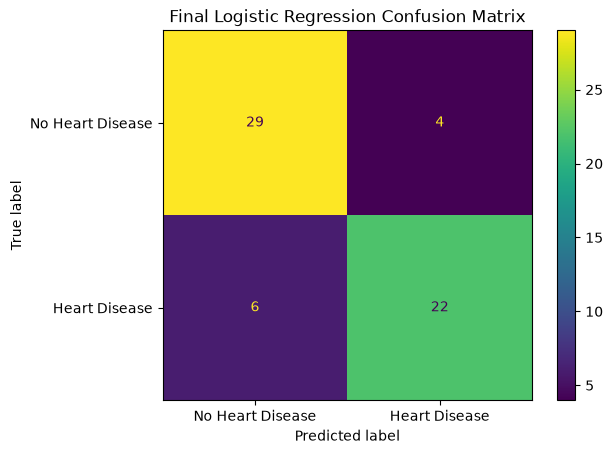

In [174]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

display.plot()

plt.title("Final Logistic Regression Confusion Matrix")
plt.show()

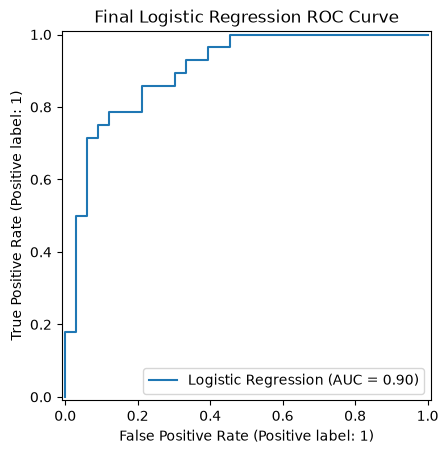

In [175]:
RocCurveDisplay.from_predictions(
    y_test,
    final_probabilities,
    name="Logistic Regression"
)

plt.title("Final Logistic Regression ROC Curve")
plt.show()

## 13. Explainable AI with SHAP

In [176]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [177]:
# Extracting Final Pipeline Components

final_preprocessor = final_model.named_steps["preprocessor"]
final_classifier = final_model.named_steps["model"]

print("Final classifier:")
print(final_classifier)

Final classifier:
LogisticRegression(C=1, max_iter=2000, random_state=1)


In [178]:
# Transform Data for SHAP

X_train_shap = final_preprocessor.transform(X_train)
X_test_shap = final_preprocessor.transform(X_test)

feature_names = final_preprocessor.get_feature_names_out()

print("Training SHAP matrix shape:", X_train_shap.shape)
print("Test SHAP matrix shape:", X_test_shap.shape)
print("Number of feature names:", len(feature_names))

Training SHAP matrix shape: (242, 28)
Test SHAP matrix shape: (61, 28)
Number of feature names: 28


In [179]:
# Creating SHAP DataFrames

X_train_shap_df = pd.DataFrame(
    X_train_shap,
    columns=feature_names,
    index=X_train.index
)

X_test_shap_df = pd.DataFrame(
    X_test_shap,
    columns=feature_names,
    index=X_test.index
)

X_test_shap_df.head()

,numerical__age,numerical__trestbps,numerical__chol,numerical__thalach,numerical__oldpeak,categorical__sex_0.0,categorical__sex_1.0,categorical__cp_1.0,categorical__cp_2.0,categorical__cp_3.0,...,categorical__slope_1.0,categorical__slope_2.0,categorical__slope_3.0,categorical__ca_0.0,categorical__ca_1.0,categorical__ca_2.0,categorical__ca_3.0,categorical__thal_3.0,categorical__thal_6.0,categorical__thal_7.0
240,-1.565654,-1.235219,-0.206934,0.139197,-0.917683,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
105,-0.057987,-1.348298,1.168119,0.269594,-0.917683,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
280,0.289936,-1.235219,1.651245,-0.295458,1.641817,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
65,0.637859,0.743655,0.666411,-0.338923,1.471184,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
104,-0.637859,-0.669827,-1.080278,-0.469320,0.788650,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [180]:
# Creating SHAP Explainer

explainer = shap.Explainer(
    final_classifier,
    X_train_shap_df
)

shap_values = explainer(X_test_shap_df)

print("SHAP values shape:", shap_values.values.shape)

Background dataset has 242 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=242 when initializing the masker.


SHAP values shape: (61, 28)


### 13.1 Human-Readable SHAP Visualizations


In [181]:
feature_name_mapping = {
    "numerical__age": "Age",
    "numerical__trestbps": "Resting Blood Pressure",
    "numerical__chol": "Serum Cholesterol",
    "numerical__thalach": "Maximum Heart Rate",
    "numerical__oldpeak": "ST Depression",

    "categorical__sex_0.0": "Sex: Female",
    "categorical__sex_1.0": "Sex: Male",

    "categorical__cp_1.0": "Chest Pain: Typical Angina",
    "categorical__cp_2.0": "Chest Pain: Atypical Angina",
    "categorical__cp_3.0": "Chest Pain: Non-anginal Pain",
    "categorical__cp_4.0": "Chest Pain: Asymptomatic",

    "categorical__fbs_0.0": "Fasting Blood Sugar: Normal",
    "categorical__fbs_1.0": "Fasting Blood Sugar: High",

    "categorical__restecg_0.0": "Resting ECG: Normal",
    "categorical__restecg_1.0": "Resting ECG: ST-T Abnormality",
    "categorical__restecg_2.0": "Resting ECG: LV Hypertrophy",

    "categorical__exang_0.0": "Exercise-Induced Angina: No",
    "categorical__exang_1.0": "Exercise-Induced Angina: Yes",

    "categorical__slope_1.0": "ST Slope: Upsloping",
    "categorical__slope_2.0": "ST Slope: Flat",
    "categorical__slope_3.0": "ST Slope: Downsloping",

    "categorical__ca_0.0": "Major Vessels: 0",
    "categorical__ca_1.0": "Major Vessels: 1",
    "categorical__ca_2.0": "Major Vessels: 2",
    "categorical__ca_3.0": "Major Vessels: 3",

    "categorical__thal_3.0": "Thal: Normal",
    "categorical__thal_6.0": "Thal: Fixed Defect",
    "categorical__thal_7.0": "Thal: Reversible Defect"
}

In [182]:
# Rename SHAP Feature Labels

clean_feature_names = [
    feature_name_mapping.get(name, name)
    for name in feature_names
]

print("Readable feature names created:", len(clean_feature_names))


Readable feature names created: 28


In [183]:
# Creating Clean SHAP DataFrame

X_test_shap_clean = X_test_shap_df.copy()
X_test_shap_clean.columns = clean_feature_names

X_train_shap_clean = X_train_shap_df.copy()
X_train_shap_clean.columns = clean_feature_names

print("Clean SHAP DataFrames created.")


Clean SHAP DataFrames created.


In [184]:
# Creating Clean SHAP Explanation Object

clean_shap_values = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test_shap_clean.values,
    feature_names=clean_feature_names
)

print("Clean SHAP object created.")

Clean SHAP object created.


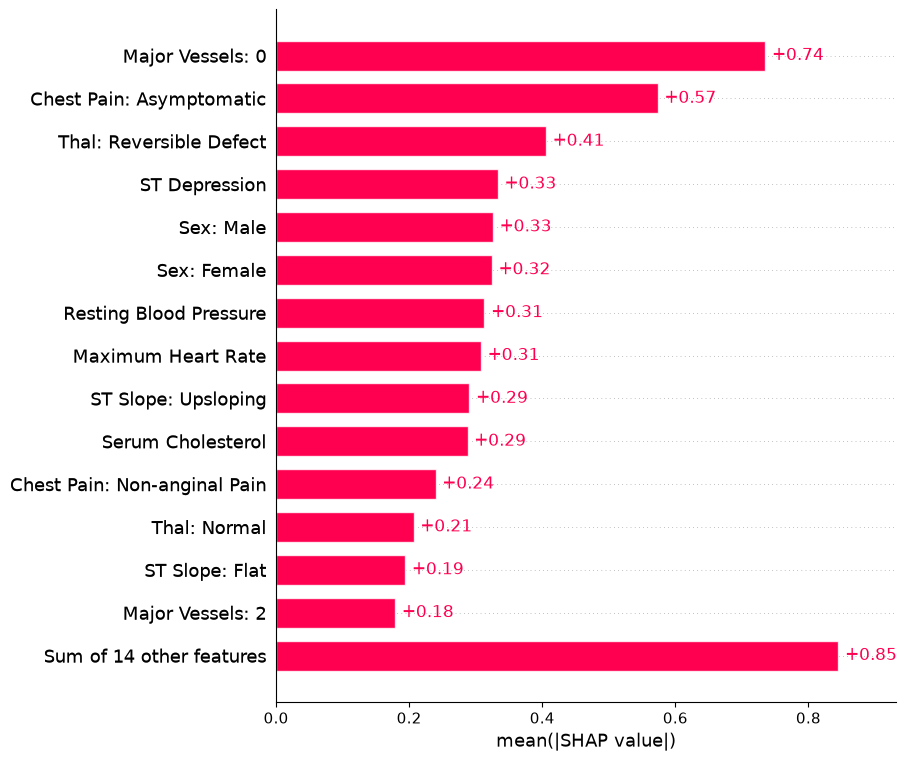

In [185]:
shap.plots.bar(
    clean_shap_values,
    max_display=15
)

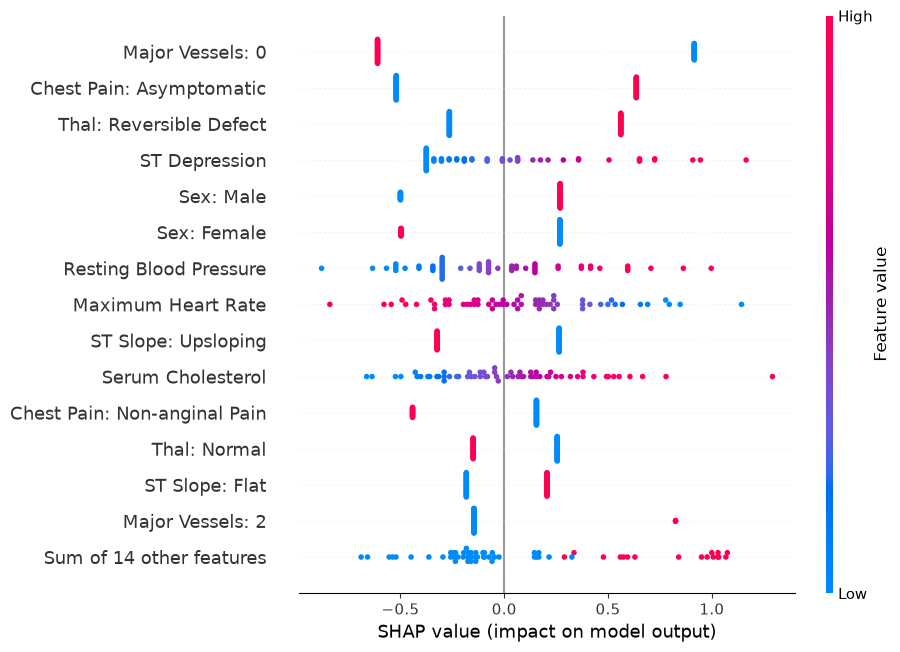

In [186]:
shap.plots.beeswarm(
    clean_shap_values,
    max_display=15
)

In [187]:
positive_indices = np.where(final_predictions == 1)[0]

positive_patient_index = positive_indices[0]

patient_data_positive = X_test.iloc[[positive_patient_index]]

positive_prediction = final_model.predict(patient_data_positive)[0]
positive_probability = final_model.predict_proba(
    patient_data_positive
)[0, 1]

print("Patient position in test set:", positive_patient_index)
print("Predicted class:", positive_prediction)
print(
    f"Predicted probability of heart disease: "
    f"{positive_probability:.4f}"
)

Patient position in test set: 2
Predicted class: 1
Predicted probability of heart disease: 0.9945


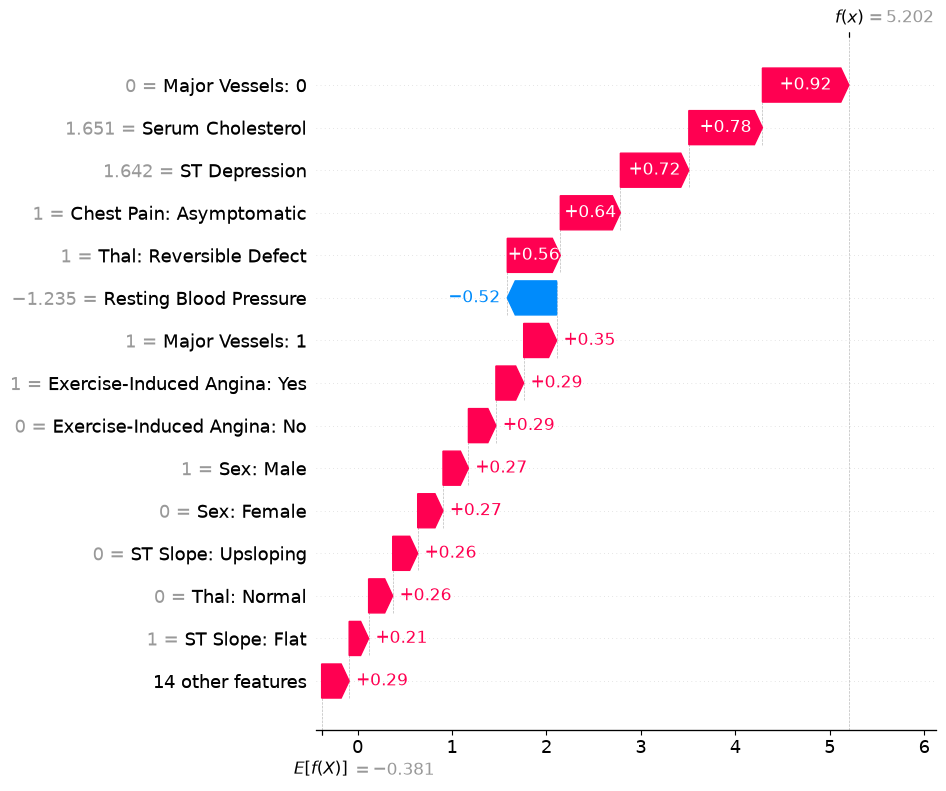

In [188]:
shap.plots.waterfall(
    clean_shap_values[positive_patient_index],
    max_display=15
)

In [189]:
# Global SHAP Importance Table

mean_abs_shap = np.abs(
    clean_shap_values.values
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Mean Absolute SHAP Value": mean_abs_shap
})

shap_importance_df = shap_importance_df.sort_values(
    by="Mean Absolute SHAP Value",
    ascending=False
).reset_index(drop=True)

shap_importance_df.head(15).round(4)

,Feature,Mean Absolute SHAP Value
0,Major Vessels: 0,0.7352
1,Chest Pain: Asymptomatic,0.5735
2,Thal: Reversible Defect,0.4056
3,ST Depression,0.3332
4,Sex: Male,0.3260
5,Sex: Female,0.3243
6,Resting Blood Pressure,0.3132
7,Maximum Heart Rate,0.3080
8,ST Slope: Upsloping,0.2906
9,Serum Cholesterol,0.2877


### Model Selection Note

Model selection was based primarily on **5-fold stratified cross-validation**, while the holdout test set was used to report final predictive performance. Because the dataset is small, cross-validation results are emphasized when comparing candidate models.


## 14. Final Project Summary and Interpretation


In [190]:
# Dataset Summary

dataset_summary = {
    "Number of samples": df.shape[0],
    "Number of original features": X.shape[1],
    "Number of preprocessed features": len(feature_names),
    "Training samples": X_train.shape[0],
    "Test samples": X_test.shape[0],
    "Heart disease cases": int((y == 1).sum()),
    "No heart disease cases": int((y == 0).sum())
}

pd.Series(dataset_summary)

Number of samples                  303
Number of original features         13
Number of preprocessed features     28
Training samples                   242
Test samples                        61
Heart disease cases                139
No heart disease cases             164
dtype: int64

In [191]:
# Final Model Comparison Table

final_model_comparison = cv_results_df[
    [
        "Model",
        "Accuracy Mean",
        "Precision Mean",
        "Recall Mean",
        "F1 Mean",
        "ROC-AUC Mean",
        "ROC-AUC Std"
    ]
].copy()

final_model_comparison.round(4)

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.8429,0.8413,0.8202,0.8284,0.9230,0.0258
1,Random Forest,0.8223,0.8218,0.7846,0.8014,0.9102,0.0170
2,SVM,0.8513,0.8597,0.8115,0.8335,0.9052,0.0273
3,KNN,0.8141,0.8479,0.7300,0.7830,0.8838,0.0296
4,Gradient Boosting,0.7894,0.7948,0.7304,0.7605,0.8769,0.0241
5,Decision Tree,0.7314,0.7060,0.7123,0.7076,0.7302,0.0283


In [192]:
# Tuned Candidate Comparison

tuned_comparison.round(4)

,Model,Best CV ROC-AUC
0,Logistic Regression,0.9230
1,SVM,0.9174
2,Random Forest,0.9152


In [193]:
# Final Test Results Table

final_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_test_results.round(4)

,Metric,Score
0,Accuracy,0.8361
1,Precision,0.8462
2,Recall,0.7857
3,F1-score,0.8148
4,ROC-AUC,0.9015


In [194]:
# Confusion Matrix Summary

tn, fp, fn, tp = final_cm.ravel()

confusion_summary = pd.DataFrame({
    "Outcome": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

confusion_summary

,Outcome,Count
0,True Negative,29
1,False Positive,4
2,False Negative,6
3,True Positive,22


In [195]:
# Top SHAP Features

top_shap_features = shap_importance_df.head(10).copy()

top_shap_features.round(4)

,Feature,Mean Absolute SHAP Value
0,Major Vessels: 0,0.7352
1,Chest Pain: Asymptomatic,0.5735
2,Thal: Reversible Defect,0.4056
3,ST Depression,0.3332
4,Sex: Male,0.3260
5,Sex: Female,0.3243
6,Resting Blood Pressure,0.3132
7,Maximum Heart Rate,0.3080
8,ST Slope: Upsloping,0.2906
9,Serum Cholesterol,0.2877


In [196]:
# Project Results Summary

print("HEART DISEASE PREDICTION PROJECT SUMMARY")
print("=" * 50)

print(f"\nDataset size: {df.shape[0]} samples")
print(f"Original features: {X.shape[1]}")
print(f"Preprocessed features: {len(feature_names)}")

print("\nFinal Model:")
print("Logistic Regression")

print("\nCross-Validation Performance:")
print(f"Mean ROC-AUC: {logistic_grid_search.best_score_:.4f}")

print("\nFinal Test Performance:")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print("\nTop 5 SHAP Features:")
for i, row in shap_importance_df.head(5).iterrows():
    print(
        f"{i + 1}. {row['Feature']} "
        f"({row['Mean Absolute SHAP Value']:.4f})"
    )

HEART DISEASE PREDICTION PROJECT SUMMARY

Dataset size: 303 samples
Original features: 13
Preprocessed features: 28

Final Model:
Logistic Regression

Cross-Validation Performance:
Mean ROC-AUC: 0.9230

Final Test Performance:
Accuracy : 0.8361
Precision: 0.8462
Recall   : 0.7857
F1-score : 0.8148
ROC-AUC  : 0.9015

Confusion Matrix:
TN: 29
FP: 4
FN: 6
TP: 22

Top 5 SHAP Features:
1. Major Vessels: 0 (0.7352)
2. Chest Pain: Asymptomatic (0.5735)
3. Thal: Reversible Defect (0.4056)
4. ST Depression (0.3332)
5. Sex: Male (0.3260)


### Final Interpretation

The final Logistic Regression model achieved strong performance on the
holdout test set, with high recall and ROC-AUC.

Cross-validation showed that Logistic Regression, Random Forest, and SVM
performed similarly, while Logistic Regression provided a strong balance
between predictive performance, stability, simplicity, and interpretability.

SHAP analysis showed that features related to the number of major vessels,
chest pain type, thalassemia status, maximum heart rate, ST slope, and
ST depression contributed substantially to model predictions.

The model should not be interpreted as a clinical diagnostic system.
The dataset is relatively small, and the results should be considered
as a machine learning research and portfolio project rather than a
medical decision-making tool.